# Esame Laboratorio di Programmazione II - 11/09/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [1]:
#Potete importare direttamente qui le librerie che userete
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import seaborn as sns

## Esercizio 1

Un’azienda ha registrato i **costi mensili di trasporto** (in euro) per 9 mezzi:  
450, 720, 1200, 980, 510, 1500, 640, 890, 2000  

1. Calcola la **spesa totale complessiva**.  

2. I mezzi con spesa **inferiore a 700 €** ricevono un **bonus di efficienza del 10%** (cioè la spesa viene ridotta del 10%).  

3. Stampa il **risparmio totale** ottenuto dall’azienda.


In [3]:
costi = np.array([450, 720, 1200, 980, 510, 1500, 640, 890, 2000], dtype=float)
#1
spesa_tot = np.sum(costi)
print("Spesa totale: ", spesa_tot)
#2
vero_falso = costi < 700
costi[vero_falso] = costi[vero_falso]*0.9
print("Array con i nuovi costi: ", costi)
#3
risparmio = spesa_tot - np.sum(costi)
print("Risparmio totale ottenuto: ", risparmio)

Spesa totale:  8890.0
Array con i nuovi costi:  [ 405.  720. 1200.  980.  459. 1500.  576.  890. 2000.]
Risparmio totale ottenuto:  160.0


## Esercizio 2

Un’urna contiene **4 palline verdi** e **1 pallina gialla**.  
Dopo ogni estrazione la pallina viene **rimessa nell’urna**.  

1. Scrivi una funzione che simula **N estrazioni** e rappresenta i risultati con un array NumPy (`1 = verde`, `0 = gialla`).  

2. Calcola la **frequenza relativa** delle palline verdi e gialle dopo 20, 40, 60, …, 200 estrazioni.  

3. Rappresenta graficamente l’**andamento della frequenza relativa di verdi e gialle** in funzione del numero di estrazioni.


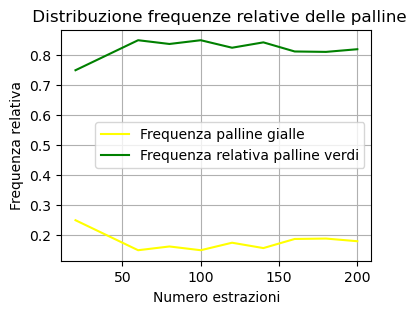

In [11]:
np.random.seed(0)
#1
def estrazioni(N):
    risultati = np.random.choice([1,0], size=N, p=(4/5,1/5))
    return risultati
#es
#2
estrazioni_totali = estrazioni(200)
controlli = np.arange(20,201,20)
freq_parz_verd = []
freq_parz_gial = []
for n in controlli:
    blocco = estrazioni_totali[:n]
    n_verdi= np.sum(blocco)
    f_verde = n_verdi/n
    f_gialla = 1-f_verde

    freq_parz_gial.append(f_gialla)
    freq_parz_verd.append(f_verde)
#3
plt.figure(figsize=(4,3))
plt.plot(controlli, freq_parz_gial, color="yellow", label="Frequenza palline gialle")
plt.plot(controlli, freq_parz_verd, color="green", label="Frequenza relativa palline verdi")
plt.title(" Distribuzione frequenze relative delle palline")
plt.xlabel("Numero estrazioni")
plt.ylabel("Frequenza relativa")
plt.grid(True)
plt.legend()
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni **5 x 7**, con valori interi casuali compresi tra 10 e 99 (inclusi).  

2. Per ogni riga, seleziona e stampa il **numero pari più grande**.  


In [16]:
np.random.seed(0)
#1
matrice = np.random.randint(10,100,(5,7))
print("Matrice: \n", matrice)
#2
massimo_pari= []
for i in range(5):
    riga = matrice[i]
    numeri_pari = []
    for x in riga:
        if x%2 == 0:
            numeri_pari.append(x)
    massimo_pari.append(max(numeri_pari))
print("Numero pari piu grande per ogni riga: \n", massimo_pari)


Matrice: 
 [[54 57 74 77 77 19 93]
 [31 46 97 80 98 98 22]
 [68 75 49 97 56 98 91]
 [47 35 87 82 19 30 90]
 [79 89 57 74 92 98 59]]
Numero pari piu grande per ogni riga: 
 [np.int32(74), np.int32(98), np.int32(98), np.int32(90), np.int32(98)]


## Esercizio 4

Utilizza il dataset `tips.csv` (contiene colonne come `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`).  

1. Conta i **valori mancanti per colonna** ed elimina le righe con valori mancanti.  

2. Crea una nuova colonna `tip_ratio` definita come:  

   \[
   \texttt{tip\_ratio} = \frac{\texttt{tip}}{\texttt{total\_bill}}
   \]  

   *(Indica la percentuale di mancia rispetto al conto totale).*  

3. **Filtra** i conti con:  
   - `total_bill` > 30  
   - `tip_ratio` > 0.15  

4. **Grafico a barre** dei **10 clienti con tip_ratio più alto** (usa l’indice del DataFrame come etichetta).  

5. **Scatter plot** con:  
   - x = `total_bill`  
   - y = `tip`  
   - colore dei punti = `tip_ratio`.  


Valori mancanti per colonna: 
 total_bill    0
tip           1
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
Dataset filtrato : 
      total_bill    tip   sex smoker   day    time  size  tip_ratio
23        39.42   7.58  Male     No   Sat  Dinner     4   0.192288
39        31.27   5.00  Male     No   Sat  Dinner     3   0.159898
44        30.40   5.60  Male     No   Sun  Dinner     4   0.184211
47        32.40   6.00  Male     No   Sun  Dinner     4   0.185185
83        32.68   5.00  Male    Yes  Thur   Lunch     2   0.152999
141       34.30   6.70  Male     No  Thur   Lunch     6   0.195335
170       50.81  10.00  Male    Yes   Sat  Dinner     3   0.196812
212       48.33   9.00  Male     No   Sat  Dinner     4   0.186220


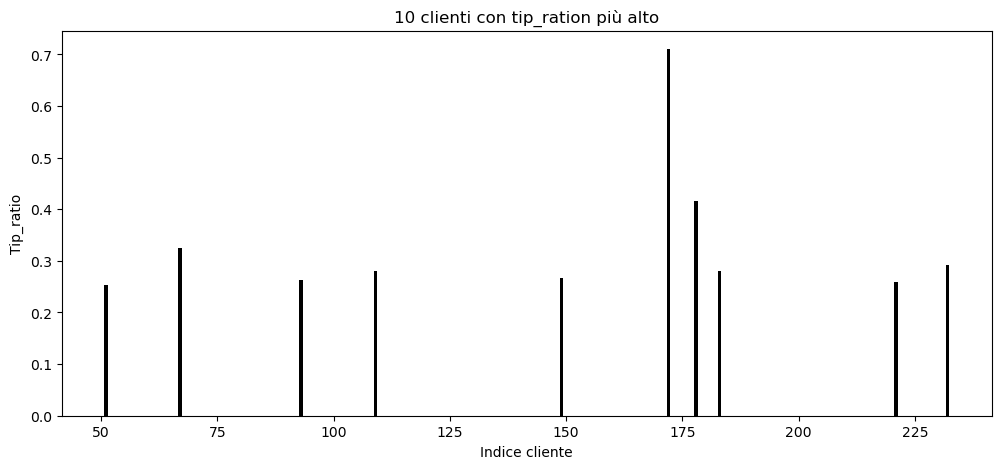

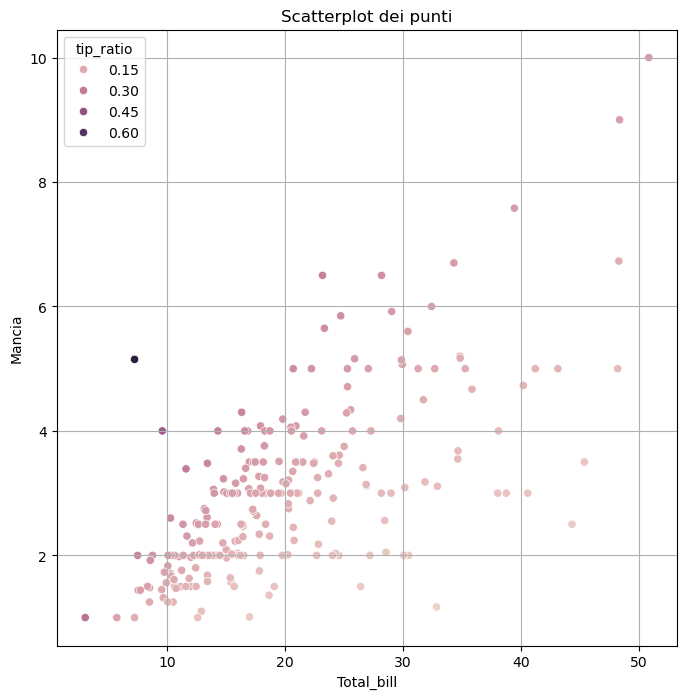

In [28]:
df = pd.read_csv("tips.csv")
#1
val_manc_col = df.isnull().sum()
print("Valori mancanti per colonna: \n", val_manc_col)
df = df.dropna()
#2
df["tip_ratio"] = (df["tip"])/(df["total_bill"])
#3
filtraggio =df[(df["total_bill"]> 30) & (df["tip_ratio"]>0.15)]
print("Dataset filtrato : \n", filtraggio)
#4
df_ordinato = df.sort_values(by="tip_ratio", ascending = False).head(10)
indici_df = df_ordinato.index
plt.figure(figsize=(12,5))
plt.bar(indici_df, df_ordinato["tip_ratio"], color="black")
plt.title("10 clienti con tip_ration più alto")
plt.xlabel("Indice cliente")
plt.ylabel("Tip_ratio")
plt.show()
#5
plt.figure(figsize=(8,8))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="tip_ratio")
plt.title("Scatterplot dei punti")
plt.xlabel("Total_bill")
plt.ylabel("Mancia")
plt.grid(True)
plt.show()

## Esercizio 5

Utilizza il dataset `tips.csv`.  

1. Quante **righe e colonne** ha il dataset? Successivamente elimina la colonna `time` dal DataFrame.  
2. Trova il **giorno (`day`) più frequente** nel dataset.  
3. Calcola la **media del conto totale (`total_bill`) per ciascun giorno** e ordina i risultati.  
4. Crea un **boxplot** dei valori di `tip` raggruppati per giorno (`day`).  
5. Crea un **violin plot** della distribuzione del `tip_ratio` (mancia/conto) per ciascun giorno della settimana.  

Bonus (Per i punti 4 e 5 dividere i risultati anche per sesso)

Numero righe e colonne del dataset: (244, 7)
Il giorno più frequente è:  Sat
Media del conto per ciascun giorno: 
 day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64


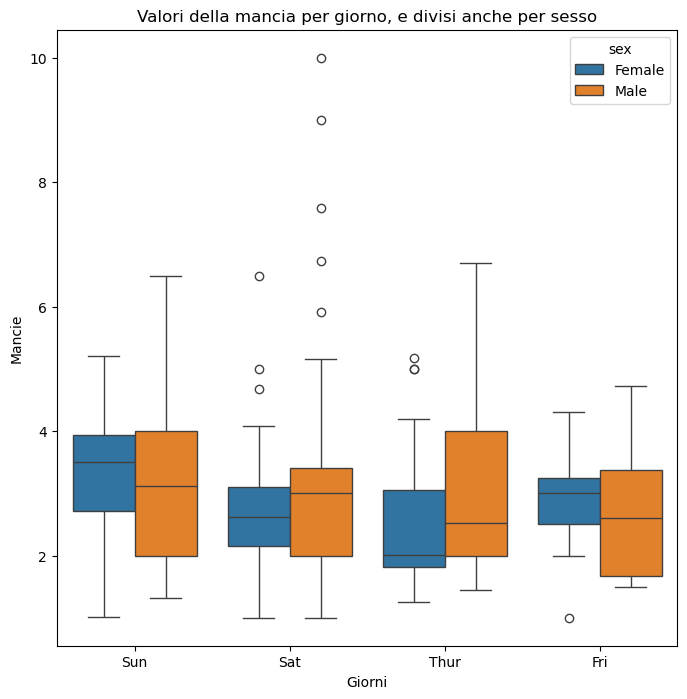

Text(0, 0.5, 'Tip_ratio')

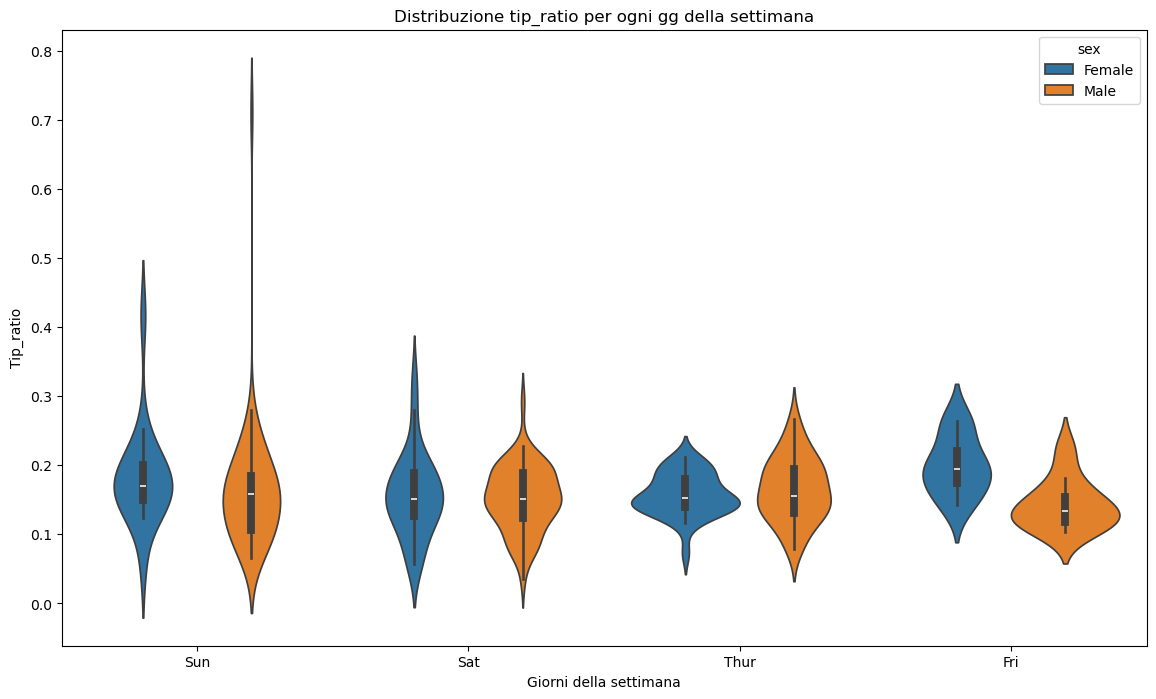

In [39]:
df = pd.read_csv("tips.csv")
#1
dimensioni = df.shape
print("Numero righe e colonne del dataset:", dimensioni)
df = df.drop(columns="time")
#2
giorno_freq = df["day"].mode()[0]
print("Il giorno più frequente è: ", giorno_freq)
#3
media_xgg = df.groupby("day")["total_bill"].mean()
print("Media del conto per ciascun giorno: \n", media_xgg)
#4
plt.figure(figsize=(8,8))
sns.boxplot(data =df, x="day", y="tip", hue="sex")
plt.title("Valori della mancia per giorno, e divisi anche per sesso")
plt.xlabel("Giorni")
plt.ylabel("Mancie")
plt.show()
#5
df["tip_ratio"]=df["tip"]/df["total_bill"]
plt.figure(figsize=(14,8))
sns.violinplot(data=df, x="day", y="tip_ratio", hue="sex")
plt.title("Distribuzione tip_ratio per ogni gg della settimana")
plt.xlabel("Giorni della settimana")
plt.ylabel("Tip_ratio")

## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.  

1. Stima i parametri della retta del tipo  

   \[
   y = a \cdot x + b
   \]  

2. Plotta i punti originali e la retta ottenuta.  

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$  

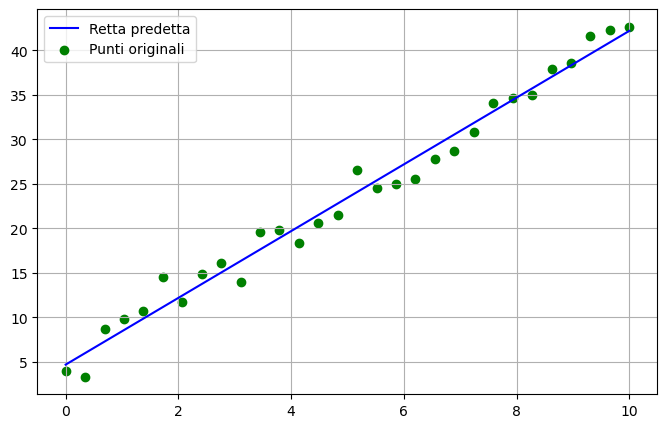

MAE: 1.3702968267678388, RMSE: 1.5627464698505418


In [42]:
x = np.array([
  0.0, 0.3448, 0.6897, 1.0345, 1.3793, 1.7241,
  2.0690, 2.4138, 2.7586, 3.1034, 3.4483, 3.7931,
  4.1379, 4.4828, 4.8276, 5.1724, 5.5172, 5.8621,
  6.2069, 6.5517, 6.8966, 7.2414, 7.5862, 7.9310,
  8.2759, 8.6207, 8.9655, 9.3103, 9.6552, 10.0
])

y = np.array([
   3.99,  3.33,  8.71,  9.83, 10.69, 14.59,
  11.72, 14.87, 16.06, 13.93, 19.61, 19.83,
  18.40, 20.59, 21.45, 26.51, 24.57, 24.94,
  25.55, 27.78, 28.71, 30.87, 34.14, 34.65,
  35.01, 37.94, 38.53, 41.56, 42.28, 42.65
])
#1
def modello_retta(x,a,b):
    return a*x + b
parametri, cov = curve_fit(modello_retta, x,y)
a_pred, b_pred = parametri
y_pred = modello_retta(x, a_pred, b_pred)
#2
plt.figure(figsize=(8,5))
plt.plot(x, y_pred, color="blue", label="Retta predetta")
plt.scatter(x, y, color = "green", label="Punti originali")
plt.legend()
plt.grid(True)
plt.show()
#3
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
print(f"MAE: {mae}, RMSE: {rmse}")